#Library

In [ ]:
!pip install scikeras

In [ ]:
import zipfile
import os
import numpy as np
import librosa
import soundfile as sf
from tqdm import tqdm
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix
import random
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV

#Data

In [ ]:
zip_path = "data.zip"
extract_path = "/content/datas"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

#Data augmentasi

In [ ]:
input_dir = "/content/datas/dataset dl"
aug_dir = "/content/data_augmented_audio_kel39"
os.makedirs(aug_dir, exist_ok=True)

def augment_audio(y):
    augmented = []

    # 1. Noise Injection
    noise = y + 0.005 * np.random.randn(len(y))
    augmented.append(noise)

    # 2. Time Shift
    shift = np.random.randint(-200, 200)
    shift_audio = np.roll(y, shift)
    augmented.append(shift_audio)

    # 3. Gain Change
    gain = np.random.uniform(0.8, 1.2)
    gain_audio = y * gain
    augmented.append(gain_audio)

    return augmented


In [ ]:
sr = 16000

for note in sorted(os.listdir(input_dir)):
    folder_in = os.path.join(input_dir, note)
    folder_out = os.path.join(aug_dir, note)
    os.makedirs(folder_out, exist_ok=True)

    for file in tqdm(os.listdir(folder_in)):
        if file.endswith(".wav"):
            path = os.path.join(folder_in, file)
            y, sr = librosa.load(path, sr=16000)

            # simpan 3 augmentasi baru
            aug_list = augment_audio(y)

            for i, aug in enumerate(aug_list):
                save_path = os.path.join(folder_out, f"{file[:-4]}_aug{i}.wav")
                sf.write(save_path, aug, sr)

100%|██████████| 9/9 [00:00<00:00, 39.33it/s]


In [ ]:
base_path = "/content/data_augmented_audio_kel39"
output_path = "/content/mel_numpy_aug"
os.makedirs(output_path, exist_ok=True)

sr_target = 16000
duration = 1.0
n_fft = 2048
hop_length = 512
n_mels = 64

target_len = int(sr_target * duration)

In [ ]:
for note_folder in sorted(os.listdir(base_path)):
    folder_path = os.path.join(base_path, note_folder)
    if not os.path.isdir(folder_path):
        continue

    save_dir = os.path.join(output_path, note_folder)
    os.makedirs(save_dir, exist_ok=True)

    for file_name in tqdm(os.listdir(folder_path)):
        if not file_name.lower().endswith(".wav"):
            continue

        file_path = os.path.join(folder_path, file_name)
        try:
            y, sr = librosa.load(file_path, sr=sr_target, mono=True)

            if len(y) > target_len:
                y = y[:target_len]
            else:
                y = np.pad(y, (0, target_len - len(y)))

            y = y / np.max(np.abs(y) + 1e-8)

            mel_spec = librosa.feature.melspectrogram(
                y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels
            )
            mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

            save_path = os.path.join(save_dir, f"{os.path.splitext(file_name)[0]}.npy")
            np.save(save_path, mel_spec_db)

        except Exception as e:
            print(f"Gagal {file_name}: {e}")


100%|██████████| 27/27 [00:00<00:00, 161.01it/s]


#Data Loader

In [ ]:
data_dir = "/content/mel_numpy_aug"

# 12 keals
classes = ['c', 'c#', 'd', 'd#', 'e', 'f',
           'f#', 'g', 'g#', 'a', 'a#', 'b']

class_to_idx = {cls: i for i, cls in enumerate(classes)}
class_to_idx


{'c': 0,
 'c#': 1,
 'd': 2,
 'd#': 3,
 'e': 4,
 'f': 5,
 'f#': 6,
 'g': 7,
 'g#': 8,
 'a': 9,
 'a#': 10,
 'b': 11}

In [ ]:
file_paths = []
labels = []

for cls in classes:
    folder = os.path.join(data_dir, cls)
    for file_name in os.listdir(folder):
        if file_name.endswith(".npy"):
            file_paths.append(os.path.join(folder, file_name))
            labels.append(class_to_idx[cls])

len(file_paths), len(labels)


(324, 324)

In [ ]:
def load_npy(path, label):
    path = path.decode()

    mel = np.load(path).astype(np.float32)
    mel = np.expand_dims(mel, axis=-1)
    mel = (mel - np.mean(mel)) / (np.std(mel) + 1e-6)

    return mel, label

In [ ]:
X = tf.constant(file_paths)
y = tf.constant(labels)

dataset = tf.data.Dataset.from_tensor_slices((X, y))
dataset = dataset.shuffle(5000)

def tf_loader(path, label):
    mel, label = tf.numpy_function(load_npy, [path, label], [tf.float32, tf.int32])
    mel.set_shape((128, 32, 1))
    label.set_shape(())
    return mel, label

dataset = dataset.map(tf_loader, num_parallel_calls=tf.data.AUTOTUNE)

In [ ]:
total = len(file_paths)
train_size = int(0.8 * total)

train_ds = dataset.take(train_size)
test_ds  = dataset.skip(train_size)

In [ ]:
def augment(mel, label):
    mel = tf.image.random_flip_left_right(mel)
    mel = tf.image.random_brightness(mel, max_delta=0.1)
    return mel, label

train_ds = train_ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)

In [ ]:
BATCH_SIZE = 32

train_ds = (
    train_ds
    .shuffle(500)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    test_ds
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# model

## model arsitektur


16,32,64,0.2,64,0.3,12

In [ ]:
input_shape = (128, 32, 1)


model = models.Sequential([
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=input_shape),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(16, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.SpatialDropout2D(0.3),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(12, activation='softmax')
])

model.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 32, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 32, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 16, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 16, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 8, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 8, 128)     │        18,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 8, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 4, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 16, 4, 128)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,124,700 (8.11 MB)

 Trainable params: 2,124,348 (8.10 MB)

 Non-trainable params: 352 (1.38 KB)

## random tun mod2

In [ ]:
param_space = {
    "filters1": [8, 16, 32],
    "filters2": [16, 32, 64],
    "filters3": [32, 64, 128],
    "dense_units": [64, 128, 256],
    "dropout_dense": [0.3, 0.4, 0.5],
    "dropout_spatial": [0.1, 0.2, 0.3],
    "learning_rate": [1e-2, 1e-3, 5e-4],
    "batch_size": [16, 32, 64]
}

In [ ]:
def build_model(params, input_shape=(128, 32, 1)):
    model = models.Sequential([
        layers.Conv2D(params["filters1"], (3,3), padding='same', activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(params["filters2"], (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(params["filters3"], (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.SpatialDropout2D(params["dropout_spatial"]),

        layers.Flatten(),
        layers.Dense(params["dense_units"], activation='relu'),
        layers.Dropout(params["dropout_dense"]),

        layers.Dense(12, activation='softmax')
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=params["learning_rate"])
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
def random_search(n_trials=8):
    results = []

    for i in range(n_trials):
        print(f"Percobaan {i+1}/{n_trials}")

        params = {k: random.choice(v) for k, v in param_space.items()}
        print("Parameter:", params)

        model = build_model(params)

        history = model.fit(
            train_ds,
            validation_data=test_ds,
            epochs=20,
            batch_size=params["batch_size"],
            verbose=0
        )

        best_val_acc = max(history.history["val_accuracy"])
        print("Best Val Accuracy:", best_val_acc)

        results.append((params, best_val_acc))

    return results

In [ ]:
results = random_search(n_trials=8)
best_params, best_acc = max(results, key=lambda x: x[1])
print(best_params)
print("Val Accuracy:", best_acc)

Percobaan 1/8
Parameter: {'filters1': 16, 'filters2': 64, 'filters3': 32, 'dense_units': 256, 'dropout_dense': 0.5, 'dropout_spatial': 0.2, 'learning_rate': 0.0005, 'batch_size': 16}
Best Val Accuracy: 0.7692307829856873
Percobaan 2/8
Parameter: {'filters1': 16, 'filters2': 16, 'filters3': 64, 'dense_units': 256, 'dropout_dense': 0.5, 'dropout_spatial': 0.2, 'learning_rate': 0.0005, 'batch_size': 32}
Best Val Accuracy: 0.9384615421295166
Percobaan 3/8
Parameter: {'filters1': 8, 'filters2': 32, 'filters3': 128, 'dense_units': 256, 'dropout_dense': 0.3, 'dropout_spatial': 0.3, 'learning_rate': 0.0005, 'batch_size': 64}
Best Val Accuracy: 0.9384615421295166
Percobaan 4/8
Parameter: {'filters1': 16, 'filters2': 64, 'filters3': 64, 'dense_units': 64, 'dropout_dense': 0.3, 'dropout_spatial': 0.2, 'learning_rate': 0.0005, 'batch_size': 64}
Best Val Accuracy: 0.8769230842590332
Percobaan 5/8
Parameter: {'filters1': 16, 'filters2': 32, 'filters3': 32, 'dense_units': 64, 'dropout_dense': 0.3, 'd

## comp

In [ ]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
callback = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.7, patience=2)
,
]

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=30,
    callbacks=callback
)


Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 646ms/step - accuracy: 0.0715 - loss: 7.7333 - val_accuracy: 0.2154 - val_loss: 2.4123 - learning_rate: 0.0010
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.1801 - loss: 3.0257 - val_accuracy: 0.2769 - val_loss: 2.3860 - learning_rate: 0.0010
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.2573 - loss: 2.2267 - val_accuracy: 0.4769 - val_loss: 2.3178 - learning_rate: 0.0010
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3311 - loss: 1.9516 - val_accuracy: 0.5077 - val_loss: 2.2178 - learning_rate: 0.0010
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3894 - loss: 1.6899 - val_accuracy: 0.4462 - val_loss: 2.2229 - learning_rate: 0.0010
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5506 - loss: 1.3636 - val_accuracy: 0.3538 - val_loss: 2.0696 - learning_rate: 0.0010
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6309 - loss: 1.0514 - val_accuracy: 0.461

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9806 - loss: 0.0784 
Test Accuracy: 0.9846153855323792


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


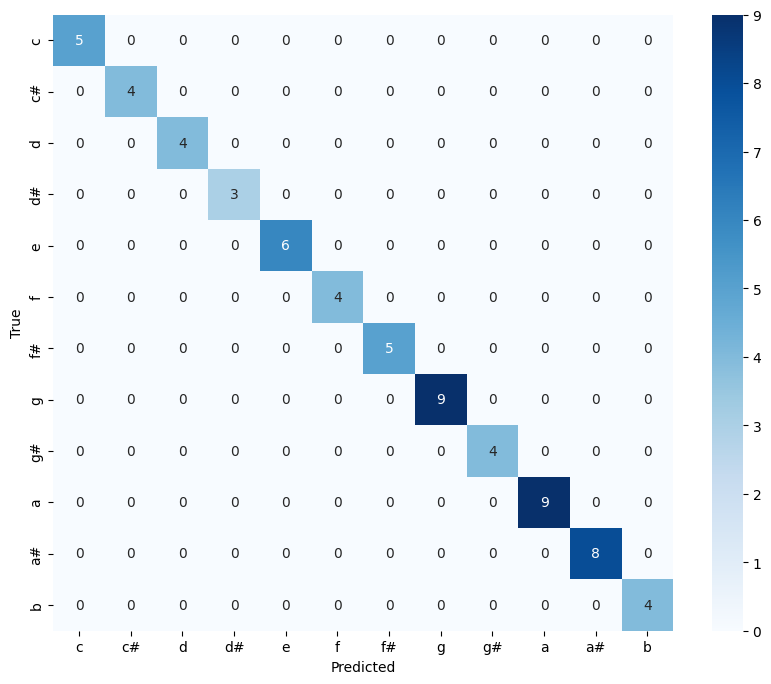

In [ ]:
true_labels = []
pred_labels = []

for x, y in test_ds:
    preds = model.predict(x)
    pred = preds.argmax(axis=1)

    true_labels.extend(y.numpy())
    pred_labels.extend(pred)

cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


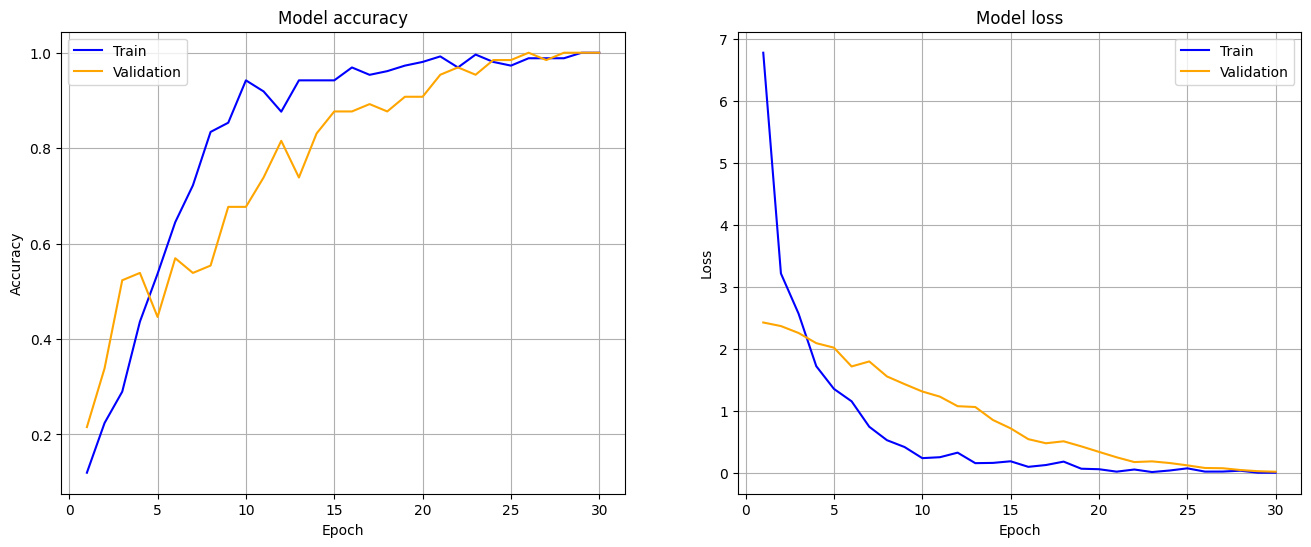

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, label='Train', color='blue')
plt.plot(epochs, val_acc, label='Validation', color='orange')
plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, label='Train', color='blue')
plt.plot(epochs, val_loss, label='Validation', color='orange')
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


# coba test ah

In [ ]:
def load_and_normalize(path, target_len=16000):
    y, sr = librosa.load(path, sr=16000)

    if len(y) > target_len:
        y = y[:target_len]
    else:
        y = np.pad(y, (0, target_len - len(y)))

    return y



In [ ]:
def to_melspectrogram(y):
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=16000,
        n_fft=2048,
        hop_length=512,
        n_mels=128
    )
    mel = librosa.power_to_db(mel, ref=np.max)
    mel = mel[:, :32]
    mel = mel.astype(np.float32)
    mel = np.expand_dims(mel, axis=-1)
    return mel


In [ ]:
notes = ["c","c#","d","d#","e","f","f#","g","g#","a","a#","b"]

y = load_and_normalize("/content/Rekaman (6).m4a")
mel = to_melspectrogram(y)

mel_input = np.expand_dims(mel, axis=0)

pred = model.predict(mel_input)
pred_class = np.argmax(pred)

print("Nada terdeteksi:", notes[pred_class])


/tmp/ipython-input-1651099726.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Nada terdeteksi: c#
